# 第2章 Notebook：形態比較と放熱効率

対応章: [`../chapters/02_stegosaurus_heat_shape.md`](../chapters/02_stegosaurus_heat_shape.md)

この notebook は、卒業研究準備セミナーの数値実験用である。上から順に実行すれば、本文で説明した図を再現できる。設定パラメータは上部のセルにまとめてある。乱数は seed を固定している。

## 1. ライブラリ読み込みと共通パラメータ

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

k = 20.0; T_b = 40.0; T_air = 25.0
theta_b = T_b - T_air
L = 0.40           # common height [m]
V_target = 2.0e-3  # common volume [m^3]
h0 = 25.0          # reference convection coefficient

## 2. 形状の幾何量（簡略化したフィン近似）

各形状を「断面積 $A_c$・周長 $P$・体積 $V$・表面積 $A$」を持つフィンとみなす。体積係数 cV は、尖った形状で 1/3、板状で 1/2 とする（簡略化）。

In [3]:
def shape_geom(kind, s, L):
    if kind == 'cone_spike':
        r = s; Ac = np.pi * r**2; P = 2 * np.pi * r; cV = 1/3
    elif kind == 'flat_spike':
        a = s; b = 0.30 * s; Ac = np.pi * a * b
        P = np.pi * (3*(a+b) - np.sqrt((3*a+b)*(a+3*b))); cV = 1/3
    elif kind == 'tri_plate':
        w = 2.0 * s; t = 0.15 * s; Ac = w * t; P = 2*(w+t); cV = 0.5
    elif kind == 'ellip_plate':
        a = 1.2 * s; b = 0.12 * s; Ac = np.pi * a * b
        P = np.pi * (3*(a+b) - np.sqrt((3*a+b)*(a+3*b))); cV = 0.5
    else:
        raise ValueError(kind)
    V = cV * Ac * L
    A = P * L            # lateral surface (simplified, prism-like)
    return Ac, P, V, A

def fin_Q(Ac, P, L, h):
    m = np.sqrt(h * P / (k * Ac))
    return np.sqrt(h * P * k * Ac) * theta_b * np.tanh(m * L)

def scale_to_volume(kind, L, V_target):
    _, _, V0, _ = shape_geom(kind, 1.0, L)
    return np.sqrt(V_target / V0)   # V ~ s^2

## 3. 同体積での比較表

In [4]:
kinds = ['cone_spike', 'flat_spike', 'tri_plate', 'ellip_plate']
rows = []
for kind in kinds:
    s = scale_to_volume(kind, L, V_target)
    Ac, P, V, A = shape_geom(kind, s, L)
    Q = fin_Q(Ac, P, L, h0)
    rows.append([kind, Q, V, A, Q / V, Q / A])
df = pd.DataFrame(rows, columns=['shape', 'Q', 'V', 'A', 'E_V', 'E_A'])
df

,shape,Q,V,A,E_V,E_A
0,cone_spike,26.630783,0.002,0.173664,13315.391591,153.346330
1,flat_spike,30.289782,0.002,0.221313,15144.890979,136.864182
2,tri_plate,29.697241,0.002,0.314028,14848.620394,94.568888
3,ellip_plate,28.520179,0.002,0.289781,14260.089390,98.419704


## 4. 体積あたり効率 E_V と表面積あたり効率 E_A の比較

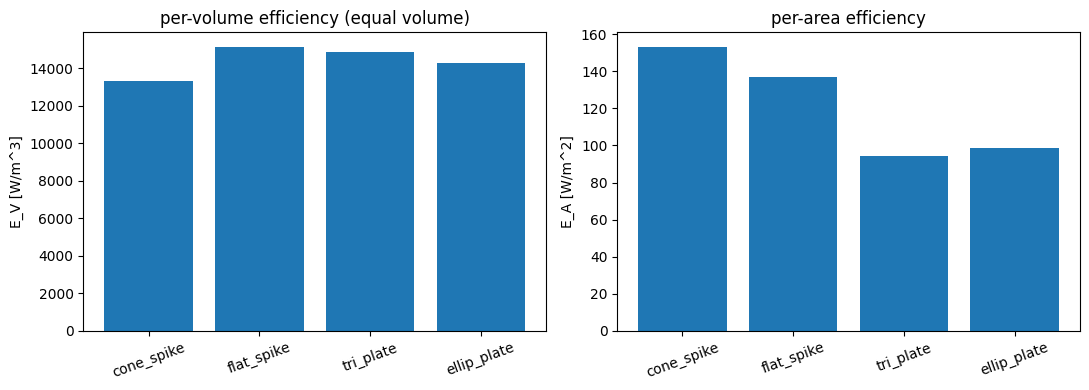

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(df['shape'], df['E_V']); ax[0].set_ylabel('E_V [W/m^3]')
ax[0].set_title('per-volume efficiency (equal volume)')
ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(df['shape'], df['E_A']); ax[1].set_ylabel('E_A [W/m^2]')
ax[1].set_title('per-area efficiency')
ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## 5. パラメータスイープ：風速（h）への感度

対流係数 h を変えたとき、各形状の体積あたり効率 E_V の順位が入れ替わるかを見る。

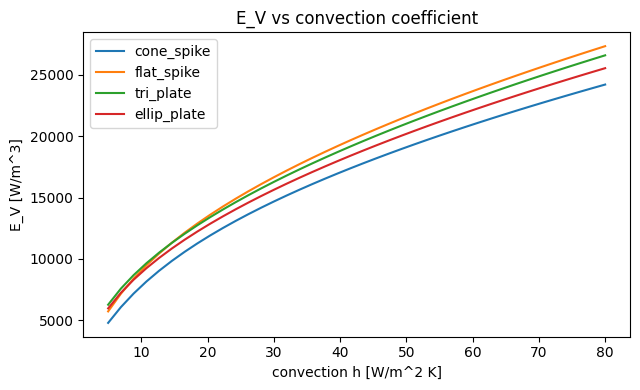

In [6]:
hs = np.linspace(5, 80, 40)
plt.figure(figsize=(6.5, 4))
for kind in kinds:
    s = scale_to_volume(kind, L, V_target)
    Ac, P, V, A = shape_geom(kind, s, L)
    Ev = np.array([fin_Q(Ac, P, L, h) / V for h in hs])
    plt.plot(hs, Ev, label=kind)
plt.xlabel('convection h [W/m^2 K]'); plt.ylabel('E_V [W/m^3]')
plt.title('E_V vs convection coefficient'); plt.legend()
plt.tight_layout(); plt.show()

## 6. 卒研でFEMに発展させる場合のメモ

ここでは 3D FEM ではなく、フィン近似で形状を比較した。卒研では同じ形状を `scikit-fem` などで 2D/3D 熱伝導として解き直し、近似がどこまで妥当かを検証できる。

## 7. 課題（自分で変更する）

1. `h0` を 2 倍にすると E_V の順位は変わるか、表を作り直して確かめよ。
2. 「同投影面積」で比較するよう正規化を変え、結論がどう変わるか調べよ。

In [7]:
# === 課題セル ===
for h0_try in [15.0, 30.0, 60.0]:
    order = sorted(kinds, key=lambda kd: -fin_Q(*shape_geom(kd, scale_to_volume(kd, L, V_target), L)[:2], L, h0_try)
                   / shape_geom(kd, scale_to_volume(kd, L, V_target), L)[2])
    print(f'h0={h0_try}: E_V ranking =', order)

h0=15.0: E_V ranking = ['flat_spike', 'tri_plate', 'ellip_plate', 'cone_spike']
h0=30.0: E_V ranking = ['flat_spike', 'tri_plate', 'ellip_plate', 'cone_spike']
h0=60.0: E_V ranking = ['flat_spike', 'tri_plate', 'ellip_plate', 'cone_spike']
